# Обработка "сырых" данных и EDA

Этап включает в себя:

1. Обработка данных, полученных парсингом карточек (шапки и основной информации)
2. Обзор данных
3. Обработка данных
4. Выводы по данным
5. Предполагаемые способы решения задачи сопоставления
6. Планирование следующих этапов, исходя из данных

In [223]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

In [224]:
df = pd.read_csv('data/hh_rezume.csv')

In [225]:
df.head()

,id,resume_url,header_text,wrapper_text,created_at,updated_at
0,1,https://hh.ru/resume/3bab3ab0000908964c0039ed1...,"Был сегодня в 14:55\nКандидат\nМужчина, 27 лет...",Аналитик\nСпециализации:\nАналитик\nТип занято...,2026-02-23 17:13:27.709 +0300,2026-02-23 17:13:27.709 +0300
1,2,https://hh.ru/resume/c0d0ac9b0002b4446d0039ed1...,"Был меньше недели назад\nКандидат\nМужчина, 32...",Аналитик данных\nСпециализации:\nАналитик\nТип...,2026-02-23 17:14:55.601 +0300,2026-02-23 17:14:55.601 +0300
2,3,https://hh.ru/resume/a28fcb6700084b93170039ed1...,"Была меньше недели назад\nКандидат\nЖенщина, 3...",Аналитик данных\n300 000 ₽ на руки\nСпециализа...,2026-02-23 17:15:11.186 +0300,2026-02-23 17:15:11.186 +0300
3,4,https://hh.ru/resume/b1b0872200090d4ab70039ed1...,"Был меньше недели назад\nКандидат\nМужчина, 24...",Аналитик данных\n180 000 ₽ на руки\nСпециализа...,2026-02-23 17:15:27.759 +0300,2026-02-23 17:15:27.759 +0300
4,5,https://hh.ru/resume/a0c1974500055dfbf30039ed1...,"Был сегодня в 11:49\nКандидат\nМужчина, 36 лет...",Аналитик\n150 000 ₽ на руки\nСпециализации:\nB...,2026-02-23 17:15:42.736 +0300,2026-02-23 17:15:42.736 +0300


In [226]:
df.shape

(7612, 6)

## Разделение данных по атрибутам

### Обработка шапки

In [227]:
s = df["header_text"]
df["gender"] = s.str.extract(r"\n(Мужчина|Женщина)\b", expand=False)
df["age"] = (
    s.str.extract(r"(?:Мужчина|Женщина),\s*(\d{1,2})\s*(?:лет|года|год)\b", expand=False)
    .astype("float")
)
df["location_line"] = s.str.split("\n").str[3].fillna("")
df["city"] = df["location_line"].str.extract(r"^([^,]+)", expand=False).str.strip()
df["relocation_status"] = df["location_line"].str.extract(
    r"(готов[а]?\s+к\s+переезду|не\s+готов[а]?\s+к\s+переезду)", expand=False
)
df["business_trips"] = df["location_line"].str.extract(
    r"(не\s+готов[а]?\s+к\s+командировкам|готов[а]?\s+к\s+редким\s+командировкам|готов[а]?\s+к\s+командировкам)",
    expand=False
)

### Обработка основнй информации


In [228]:
s = df["wrapper_text"]

In [229]:
df["salary_raw"] = s.str.extract(
    r"(по договоренности|(?:от|до)?\s*\d[\d\s]{2,12}\s*₽)", expand=False).str.lstrip("\n \t")
df["experience_raw"] = s.str.extract(
    r"(Опыт работы\s+[\d\s]+(?:лет|года|год)(?:\s+[\d\s]+(?:месяцев|месяца|месяц))?)",
    expand=False
)
df["education_block"] = s.str.extract(
    r"Образование\s*\n(.+?)(?=\n[A-ZА-ЯЁ][^\n]{0,40}\n|$)",
    expand=False,
)
df["position"] = (
    s.str.extract(r"^\s*([^\n]+)", expand=False)
     .str.replace(r"\s+", " ", regex=True)
     .str.strip()
     .replace("", pd.NA)
)

In [230]:
df.head()

,id,resume_url,header_text,wrapper_text,created_at,updated_at,gender,age,location_line,city,relocation_status,business_trips,salary_raw,experience_raw,education_block,position
0,1,https://hh.ru/resume/3bab3ab0000908964c0039ed1...,"Был сегодня в 14:55\nКандидат\nМужчина, 27 лет...",Аналитик\nСпециализации:\nАналитик\nТип занято...,2026-02-23 17:13:27.709 +0300,2026-02-23 17:13:27.709 +0300,Мужчина,27.0,"Москва, готов к переезду, готов к командировкам",Москва,готов к переезду,готов к командировкам,NaN,Опыт работы 3 года 11 месяцев,NaN,Аналитик
1,2,https://hh.ru/resume/c0d0ac9b0002b4446d0039ed1...,"Был меньше недели назад\nКандидат\nМужчина, 32...",Аналитик данных\nСпециализации:\nАналитик\nТип...,2026-02-23 17:14:55.601 +0300,2026-02-23 17:14:55.601 +0300,Мужчина,32.0,"Москва, м. Планерная, не готов к переезду, гот...",Москва,не готов к переезду,готов к редким командировкам,NaN,Опыт работы 8 лет 11 месяцев,NaN,Аналитик данных
2,3,https://hh.ru/resume/a28fcb6700084b93170039ed1...,"Была меньше недели назад\nКандидат\nЖенщина, 3...",Аналитик данных\n300 000 ₽ на руки\nСпециализа...,2026-02-23 17:15:11.186 +0300,2026-02-23 17:15:11.186 +0300,Женщина,30.0,"Москва, не готова к переезду, готова к команди...",Москва,не готова к переезду,готова к командировкам,300 000 ₽,Опыт работы 6 лет 6 месяцев,NaN,Аналитик данных
3,4,https://hh.ru/resume/b1b0872200090d4ab70039ed1...,"Был меньше недели назад\nКандидат\nМужчина, 24...",Аналитик данных\n180 000 ₽ на руки\nСпециализа...,2026-02-23 17:15:27.759 +0300,2026-02-23 17:15:27.759 +0300,Мужчина,24.0,"Москва, м. Аэропорт, не готов к переезду, гото...",Москва,не готов к переезду,готов к командировкам,180 000 ₽,Опыт работы 2 года 8 месяцев,NaN,Аналитик данных
4,5,https://hh.ru/resume/a0c1974500055dfbf30039ed1...,"Был сегодня в 11:49\nКандидат\nМужчина, 36 лет...",Аналитик\n150 000 ₽ на руки\nСпециализации:\nB...,2026-02-23 17:15:42.736 +0300,2026-02-23 17:15:42.736 +0300,Мужчина,36.0,"Санкт-Петербург, готов к переезду, готов к ком...",Санкт-Петербург,готов к переезду,готов к командировкам,150 000 ₽,Опыт работы 11 лет 5 месяцев,NaN,Аналитик


## Обработка данных

Переведем опыт работы в число - срок месяца работы в месяцах

In [231]:
s = df["experience_raw"].fillna("").str.lower()

years = pd.to_numeric(
    s.str.extract(r"(\d+)\s*(?:год|года|лет)", expand=False),
    errors="coerce"
).fillna(0)

months = pd.to_numeric(
    s.str.extract(r"(\d+)\s*(?:месяц|месяца|месяцев)", expand=False),
    errors="coerce"
).fillna(0)

df["experience_years"] = years.astype(int)
df["experience_months_part"] = months.astype(int)
df["experience_months"] = (years * 12 + months).astype(int)

## Обзор данных

Датасет по резюме включает в себя:

 - Данные о соискателе - пол, возраст, опыт работы
 - Желаемую ЗП
 - Текст резюме - предыдущие места работы, навыки и тд


### Распределения

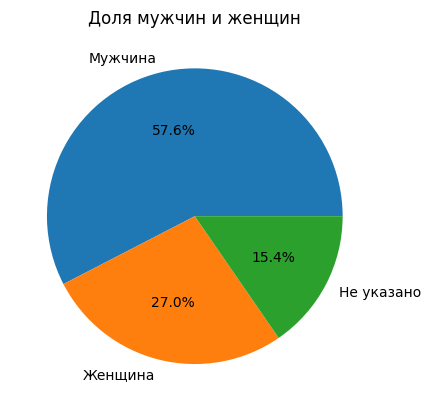

In [232]:
df["gender"] = df["gender"].fillna("Не указано")
gender_counts = df["gender"].value_counts()
plt.figure()
gender_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Доля мужчин и женщин")
plt.ylabel("")
plt.show()

In [233]:
df["position"].nunique()

4937

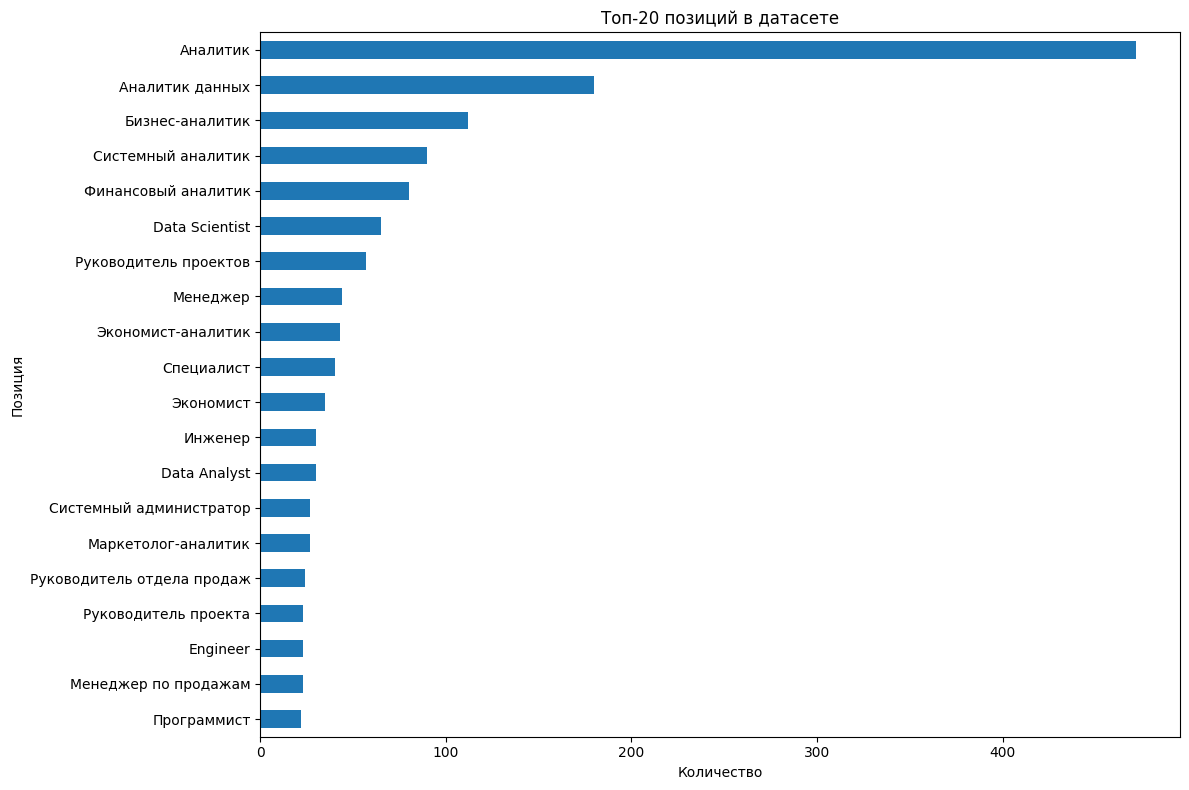

In [234]:
position_counts = (
    df["position"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12, 8)) 
position_counts.sort_values().plot(kind="barh")

plt.title("Топ-20 позиций в датасете")
plt.xlabel("Количество")
plt.ylabel("Позиция")

plt.tight_layout()
plt.show()

Как мы видим, в датасете очень много различных специальностей, часть из них вообще не связана с анализом данных

Попробуем убрать их

Сначала отберу 50 самых популярных профессий, далее - сформирую нужные, по которым проводил поиск на HH

In [235]:
df["position"].value_counts().head(50)

position
Аналитик                                     472
Аналитик данных                              180
Бизнес-аналитик                              112
Системный аналитик                            90
Финансовый аналитик                           80
Data Scientist                                65
Руководитель проектов                         57
Менеджер                                      44
Экономист-аналитик                            43
Специалист                                    40
Экономист                                     35
Инженер                                       30
Data Analyst                                  30
Системный администратор                       27
Маркетолог-аналитик                           27
Руководитель отдела продаж                    24
Engineer                                      23
Менеджер по продажам                          23
Руководитель проекта                          23
Программист                                   22
Маркетолог 

In [236]:
allowed_roles = [
    "Аналитик",
    "Data Analyst",
    "Data Engineer",
    'Инженер данных',
    "Аналитик DWH",
    "Аналитик данных",
    "BI-аналитик",
    "Data Scientist",
    "ML Engineer",
    "Системный аналитик",
    "Product Analyst",
    "Data Engineer"
]

df = df[df["position"].isin(allowed_roles)]

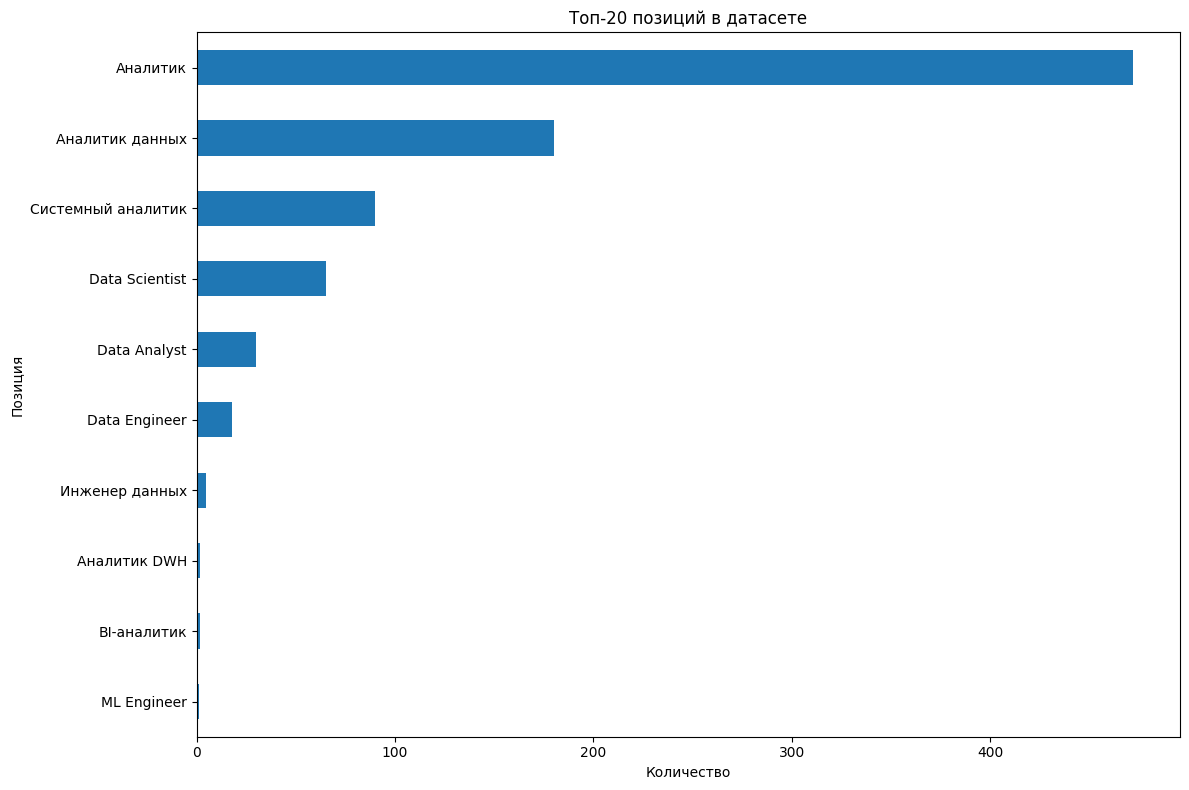

In [237]:
position_counts = (
    df["position"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12, 8)) 
position_counts.sort_values().plot(kind="barh")

plt.title("Топ-20 позиций в датасете")
plt.xlabel("Количество")
plt.ylabel("Позиция")

plt.tight_layout()
plt.show()

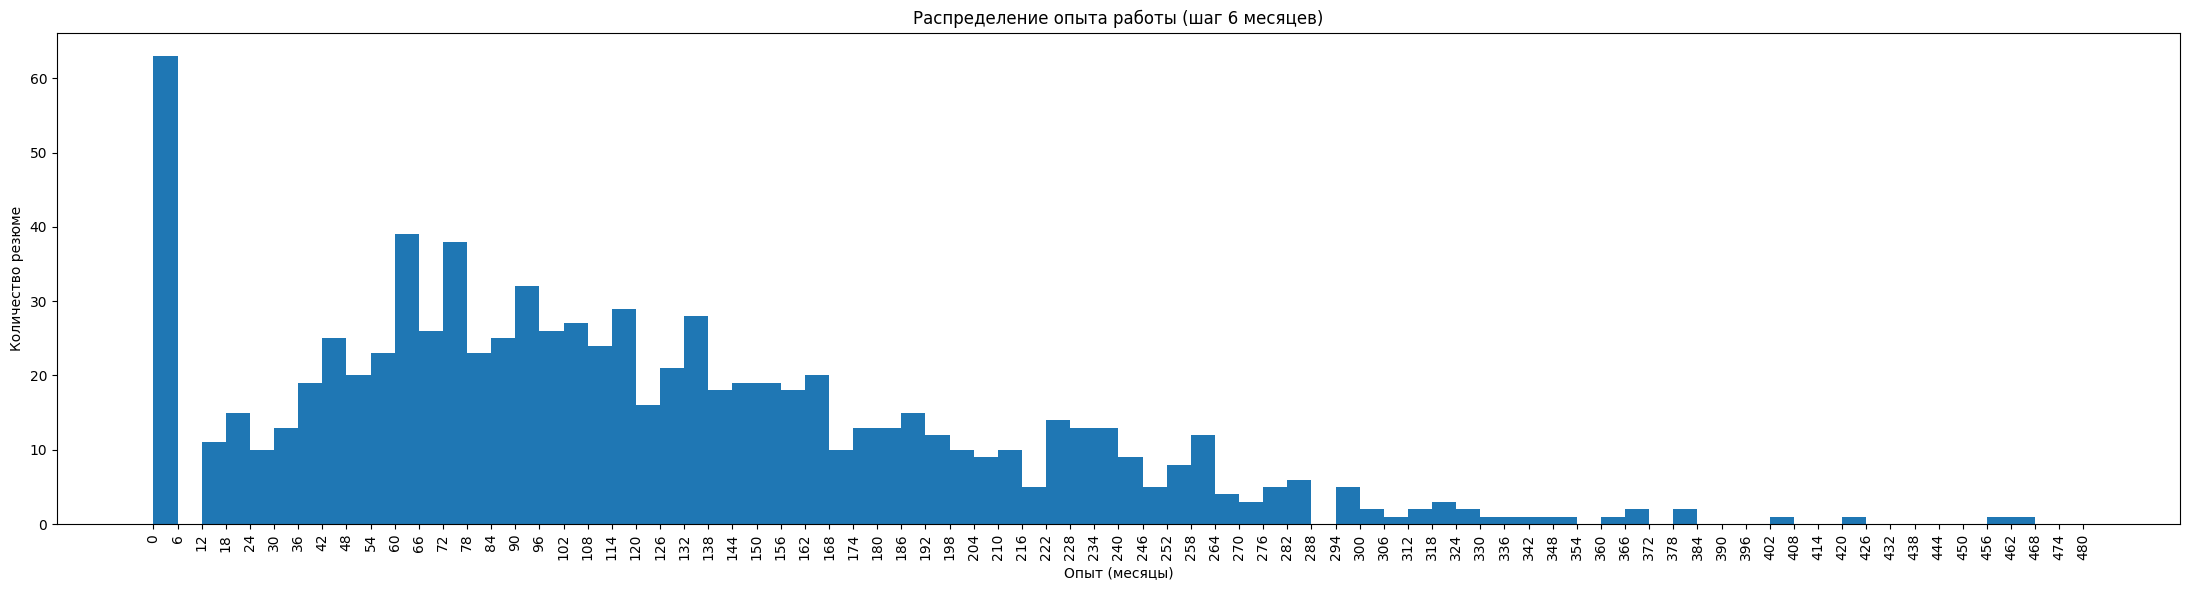

In [238]:
max_months = 480
x = df["experience_months"].dropna()
x = x[x <= max_months]

bins = np.arange(0, max_months + 6, 6)

plt.figure(figsize=(22, 6))
plt.hist(x, bins=bins)

plt.title("Распределение опыта работы (шаг 6 месяцев)")
plt.xlabel("Опыт (месяцы)")
plt.ylabel("Количество резюме")

plt.xticks(bins, rotation=90)

plt.tight_layout()
plt.show()

In [239]:
df.sort_values("experience_months", ascending=False)[
    ["experience_raw", "experience_months"]
].head(30)

,experience_raw,experience_months
2049,Опыт работы 51 год 1 месяц,613
5114,Опыт работы 38 лет 10 месяцев,466
682,Опыт работы 38 лет 4 месяца,460
383,Опыт работы 35 лет 2 месяца,422
6203,Опыт работы 33 года 8 месяцев,404
2907,Опыт работы 31 год 11 месяцев,383
540,Опыт работы 31 год 9 месяцев,381
329,Опыт работы 30 лет 8 месяцев,368
3722,Опыт работы 30 лет 6 месяцев,366
2229,Опыт работы 30 лет 4 месяца,364


В опыте работы видим явные выбросы - слишком большой срок работы

Удалим их

In [240]:
Q1 = df["experience_months"].quantile(0.25)
Q3 = df["experience_months"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df = df[df["experience_months"] <= upper_bound]

In [241]:
df.sort_values("experience_months", ascending=False)[
    ["experience_raw", "experience_months"]
].head(30)

,experience_raw,experience_months
352,Опыт работы 27 лет 4 месяца,328
468,Опыт работы 27 лет 1 месяц,325
5185,Опыт работы 26 лет 8 месяцев,320
196,Опыт работы 26 лет 8 месяцев,320
232,Опыт работы 26 лет 7 месяцев,319
90,Опыт работы 26 лет,312
549,Опыт работы 26 лет,312
942,Опыт работы 25 лет 8 месяцев,308
1939,Опыт работы 25 лет 4 месяца,304
941,Опыт работы 25 лет 1 месяц,301


In [242]:
df.shape

(851, 19)

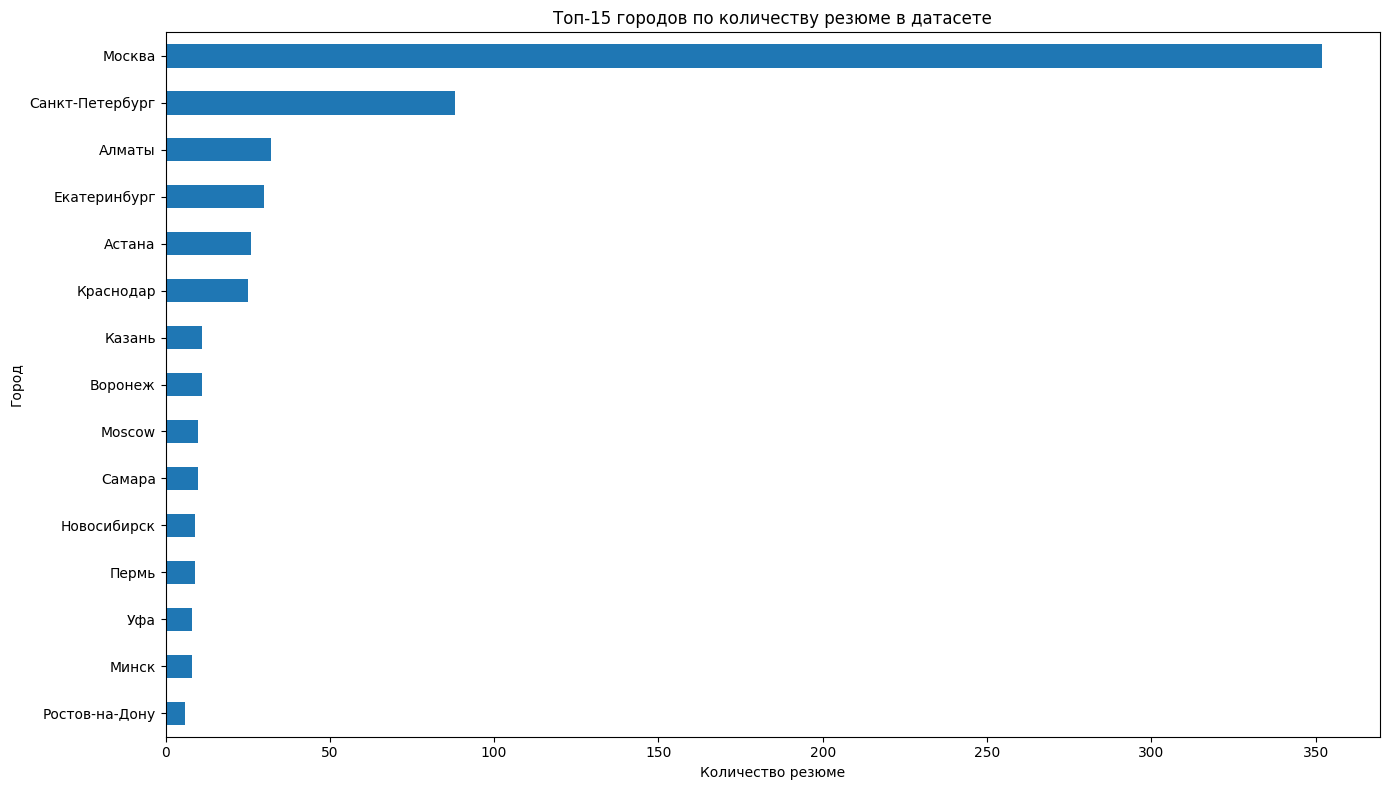

In [243]:
top_cities = df["city"].value_counts().head(15)

plt.figure(figsize=(14, 8))
top_cities.sort_values().plot(kind="barh")

plt.title("Топ-15 городов по количеству резюме в датасете")
plt.xlabel("Количество резюме")
plt.ylabel("Город")

plt.tight_layout()
plt.show()

Сразу уберем NaN

In [244]:
df["city"] = df["city"].fillna("Не указано")

Оставим только зарплату в рублях

In [245]:
mask = df["salary_raw"].isna() | df["salary_raw"].str.contains("₽", na=False)
df = df[mask].copy()

In [246]:
df.shape

(851, 19)

In [ ]:
s = df["salary_raw"].astype("string")

nums = (
    s.str.replace("\u00a0", "", regex=False)
     .str.replace(" ", "", regex=False)
     .str.findall(r"\d+")
)

df["salary_rub"] = nums.apply(
    lambda x: sum(map(int, x)) / len(x) if isinstance(x, list) and len(x) > 0 else pd.NA
).astype("Float64")

## Выводы

1) Обработка данных показала проблемы с парсингом - забираются резюме с другими специальностями, необходимо поставить парсинг по расписанию, а также дополнительно проработать алгоритм. Видим, что в финальном датасете осталось около 10% от всех полученных данных
2) в данных присутствуют явные "выбросы" - например, по возрасту или опыту работы, данные выбросы также удалены
3) При парсинге также получаем резюме "иностранного" рынка - например, Казахстан